In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
def reservation_price(mid_price, inventory, gamma, sigma, t, T):
    return mid_price - gamma * inventory * sigma**2 * (T - t) / T

def optimal_spread(gamma, sigma, k, t, T):
    return gamma * sigma**2 * (T - t) / T + (2 / gamma) * np.log(1 + gamma / k)

def execution_probability(distance, decay=0.1):
    return np.exp(-decay * distance)

def run_simulation(T, volatility, lambda_orders, gamma):
    inventory = [0]
    cash = 0
    pnl = [0]
    mid_prices = [100]
    dt = 1/(252*8*60*2) # 30s

    for t in range(T):
        mid_price = mid_prices[-1] * np.exp(np.random.normal(0, volatility) * np.sqrt(dt) - 1/2 * volatility**2 * dt)
        curr_inventory = inventory[-1]

        res_price = reservation_price(mid_price, curr_inventory, gamma, volatility, t, T)
        spread = optimal_spread(gamma, volatility, lambda_orders, t, T)

        bid_price = min(res_price - spread / 2, mid_price)
        ask_price = max(res_price + spread / 2, mid_price)

        num_orders = np.random.poisson(lambda_orders)
        is_buy_order = np.random.rand() < 0.5
        if is_buy_order:
            nb_sell = np.sum(np.where(np.random.rand(num_orders) < execution_probability(ask_price - mid_price), 1, 0))
            curr_inventory -= nb_sell
            cash += ask_price * nb_sell
        else:
            nb_buy = np.sum(np.where(np.random.rand(num_orders) < execution_probability(mid_price - bid_price), 1, 0))
            curr_inventory += nb_buy
            cash -= bid_price * nb_buy

        pnl.append(cash + curr_inventory * mid_price)
        inventory.append(curr_inventory)
        mid_prices.append(mid_price)

    return pnl, inventory, mid_prices

def get_plot(pnl, inventory, mid_price, T):
    plt.figure(figsize=(12, 6))
    plt.plot(range(T+1), pnl, label="PnL", color="blue")
    plt.title("Avellaneda-Stoikov Market Making Simulation: PnL Curve")
    plt.xlabel("Time")
    plt.ylabel("PnL")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(T+1), mid_price, label="Mid-Price", color="red")
    plt.title("Avellaneda-Stoikov Market Making Simulation: Mid-Price Curve")
    plt.xlabel("Time")
    plt.ylabel("Mid-Price")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(T+1), inventory, label="Inventory", color="green")
    plt.title("Avellaneda-Stoikov Market Making Simulation: Inventory Curve")
    plt.xlabel("Time")
    plt.ylabel("Inventory")
    plt.legend()
    plt.grid()
    plt.show()

def run_simulation_hedging(T, volatility, lambda_orders, gamma, beta):
    inventory = [0]
    hedge_inventory = [0]
    cash = 0
    pnl = [0]
    mid_prices = [100]
    hedge_prices = [beta * 100]
    dt = 1 / (252 * 8 * 60 * 2)  # 30s

    kappa = 0.5
    sigma = 2.0
    error = 0

    for t in range(T):
        mid_price = mid_prices[-1] * np.exp(np.random.normal(0, volatility) * np.sqrt(dt) - 1/2 * volatility**2 * dt)
        error = error + (-kappa * error * dt + sigma * np.sqrt(dt) * np.random.normal(0, 1))
        hedge_price = beta * mid_price + error

        curr_inventory = inventory[-1]
        curr_hedge_inventory = hedge_inventory[-1]

        res_price = reservation_price(mid_price, curr_inventory, gamma, volatility, t, T)
        spread = optimal_spread(gamma, volatility, lambda_orders, t, T)

        bid_price = min(res_price - spread / 2, mid_price)
        ask_price = max(res_price + spread / 2, mid_price)

        num_orders = np.random.poisson(lambda_orders)
        is_buy_order = np.random.rand() < 0.5
        if is_buy_order:
            nb_sell = np.sum(np.where(np.random.rand(num_orders) < execution_probability(mid_price - bid_price), 1, 0))
            curr_inventory -= nb_sell
            cash += ask_price * nb_sell
        else:
            nb_buy = np.sum(np.where(np.random.rand(num_orders) < execution_probability(ask_price - mid_price), 1, 0))
            curr_inventory += nb_buy
            cash -= bid_price * nb_buy

        curr_hedge_inventory += (inventory[-1] - curr_inventory) / beta
        cash -= (inventory[-1] - curr_inventory) * hedge_price / beta

        pnl.append(cash + curr_inventory * mid_price + curr_hedge_inventory * hedge_price)
        inventory.append(curr_inventory)
        hedge_inventory.append(curr_hedge_inventory)
        mid_prices.append(mid_price)
        hedge_prices.append(hedge_price)

    return pnl, inventory, hedge_inventory, mid_prices, hedge_prices

def get_plot_hedging(pnl, inventory, hedge_inventory, mid_price, hedge_price, T):
    plt.figure(figsize=(12, 6))
    plt.plot(range(T + 1), pnl, label="PnL", color="blue")
    plt.title("Market Making Simulation with Beta Hedging: PnL Curve")
    plt.xlabel("Time")
    plt.ylabel("PnL")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(T + 1), mid_price, label="Mid-Price", color="red")
    plt.plot(range(T + 1), hedge_price, label="Hedge Price", color="orange")
    plt.title("Market Making Simulation: Mid and Hedge Prices")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(T + 1), inventory, label="Inventory", color="green")
    plt.plot(range(T + 1), hedge_inventory, label="Hedge Inventory", color="purple")
    plt.title("Market Making Simulation with Beta Hedging: Inventory")
    plt.xlabel("Time")
    plt.ylabel("Inventory")
    plt.legend()
    plt.grid()
    plt.show()

In [36]:
T = 1000 # 1 day
volatility = 0.2
lambda_orders = 100
gamma = 0.001

### Market Making Simulation

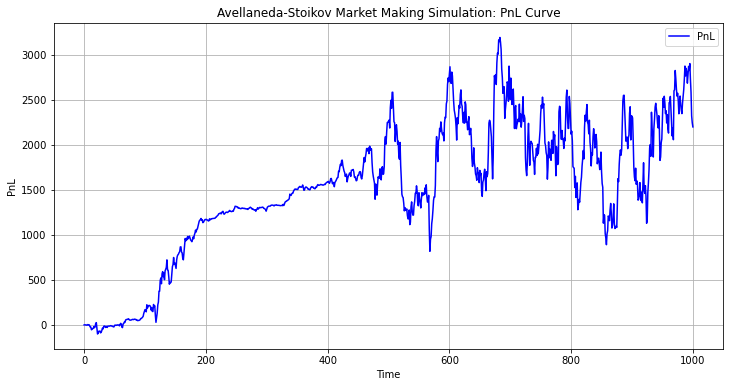

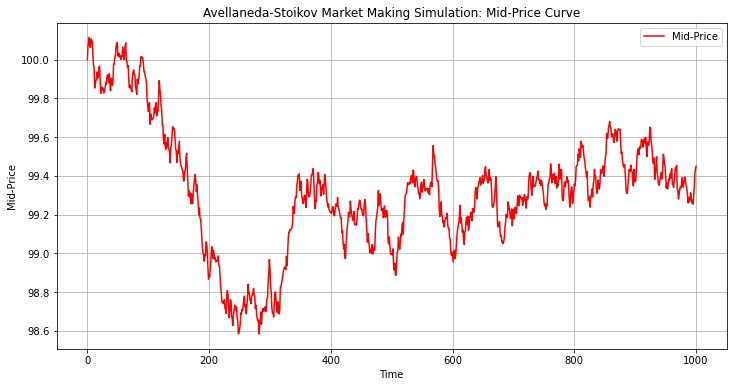

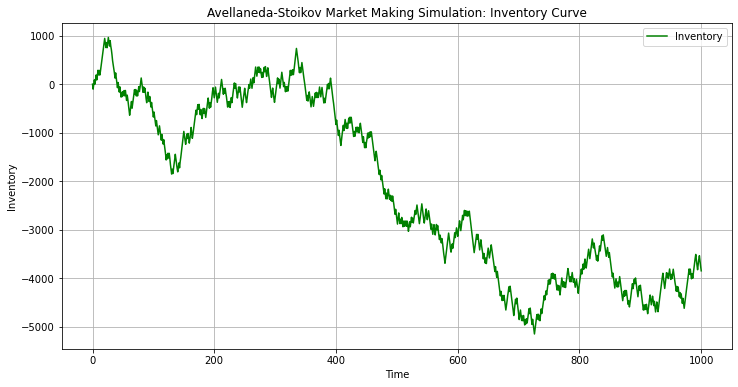

In [37]:
np.random.seed(0)
pnl, inventory, mid_price = run_simulation(T, volatility, lambda_orders, gamma)
get_plot(pnl, inventory, mid_price, T)

PnL Mean: 1851.7064924888837
PnL Std: 2719.455650332727


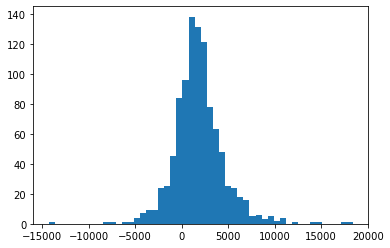

In [38]:
pnl_list = []
for i in range(1000):
    pnl, inventory, mid_price = run_simulation(T, volatility, lambda_orders, gamma)
    pnl_list.append(pnl[-1])

print(f"PnL Mean: {np.mean(pnl_list)}")
print(f"PnL Std: {np.std(pnl_list)}")
plt.hist(pnl_list, bins=50)
plt.show()

### Market Making with Beta Hedging

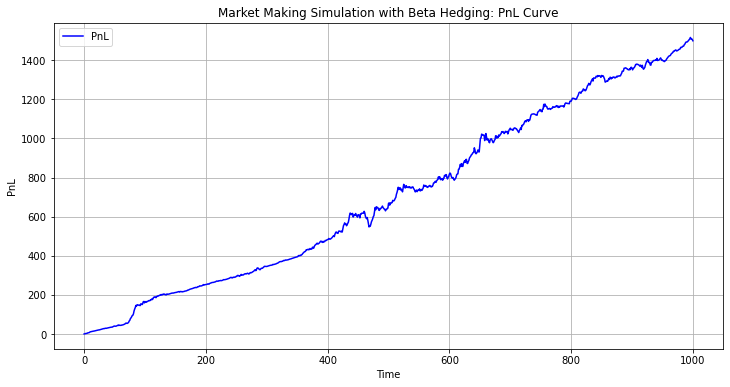

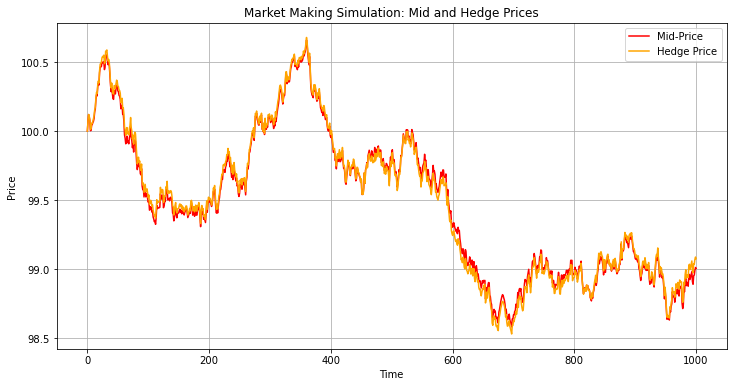

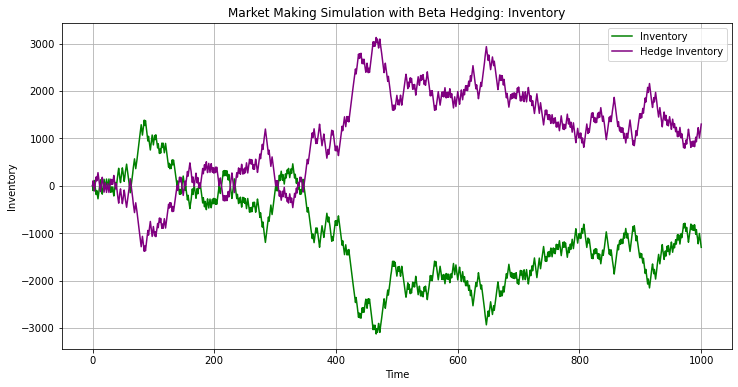

In [39]:
beta = 1
np.random.seed(0)
pnl, inventory, hedge_inventory, mid_price, hedge_price = run_simulation_hedging(T, volatility, lambda_orders, gamma, beta)
get_plot_hedging(pnl, inventory, hedge_inventory, mid_price, hedge_price, T)

PnL Mean: 1960.544466615808
PnL Std: 779.6479211561818


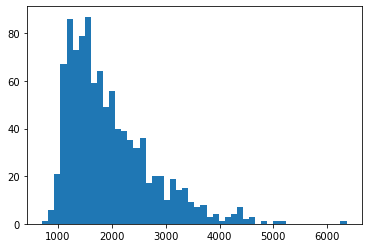

In [40]:
pnl_list = []
for i in range(1000):
    pnl, inventory, hedge_inventory, mid_price, hedge_price = run_simulation_hedging(T, volatility, lambda_orders, gamma, beta)
    pnl_list.append(pnl[-1])

print(f"PnL Mean: {np.mean(pnl_list)}")
print(f"PnL Std: {np.std(pnl_list)}")
plt.hist(pnl_list, bins=50)
plt.show()